# Pneumonia Detection from Chest X-rays

This notebook develops end-to-end deep learning pipelines for binary pneumonia detection using the Kaggle Chest X-ray Pneumonia dataset. The medical objective is to classify each radiograph as `NORMAL` or `PNEUMONIA` while following practical medical-imaging considerations such as conservative augmentation, class-imbalance handling, explainability with Grad-CAM, and held-out test evaluation.

In [3]:
pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import copy
import math
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.datasets.folder import default_loader
import kagglehub

warnings.filterwarnings("ignore")

In [5]:
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"

print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("CUDA not available. Training will run on CPU.")

Using device: cuda
GPU: NVIDIA H200 NVL MIG 1g.18gb
CUDA version: 12.8


## Dataset Loading

The Kaggle Chest X-ray Pneumonia dataset contains pediatric chest radiographs organized into `train`, `val`, and `test` folders with two classes: `NORMAL` and `PNEUMONIA`. Because the official validation folder is very small, this notebook creates a stratified validation split from the training folder for more stable model selection, while keeping the official test folder untouched for final evaluation.

In [6]:
download_root = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))
print(f"Path to dataset files: {download_root}")

kagglehub_chest_xray = download_root / "chest_xray"
CANDIDATE_DATA_ROOTS = [
    kagglehub_chest_xray,
    download_root,
    Path("./chest_xray"),
    Path("./data/chest_xray"),
    Path("/kaggle/input/chest-xray-pneumonia/chest_xray"),
]

DATA_ROOT = next(
    (
        path
        for path in CANDIDATE_DATA_ROOTS
        if (path / "train").exists() and (path / "test").exists()
    ),
    None,
 )
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Dataset not found. Place the Kaggle Chest X-ray dataset in './chest_xray' or update CANDIDATE_DATA_ROOTS."
    )

train_root = DATA_ROOT / "train"
test_root = DATA_ROOT / "test"

raw_train_index = datasets.ImageFolder(train_root)
test_index = datasets.ImageFolder(test_root)

class_names = raw_train_index.classes
label_to_idx = raw_train_index.class_to_idx

if class_names != test_index.classes:
    raise ValueError("Train and test class mappings do not match.")

targets = np.array(raw_train_index.targets)
indices = np.arange(len(targets))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.15,
    stratify=targets,
    random_state=SEED,
)

train_samples = [raw_train_index.samples[i] for i in train_indices]
val_samples = [raw_train_index.samples[i] for i in val_indices]
test_samples = list(test_index.samples)

print(f"Using dataset root: {DATA_ROOT.resolve()}")
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_samples)}")
print(f"Validation samples: {len(val_samples)}")
print(f"Test samples: {len(test_samples)}")

100%|██████████| 2.29G/2.29G [00:24<00:00, 99.6MB/s]

Extracting files...


Path to dataset files: /home/kp2469/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
Using dataset root: /home/kp2469/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray
Classes: ['NORMAL', 'PNEUMONIA']
Train samples: 4433
Validation samples: 783
Test samples: 624


## Data Preprocessing and Augmentation

Chest X-rays are grayscale, but pretrained ImageNet backbones expect 3-channel input, so images are converted to 3 channels after grayscale normalization. Augmentation is kept conservative: resize to a fixed input size, small random rotations, and low-probability horizontal flips. This helps regularization without introducing unrealistic anatomical distortions. ImageNet normalization is used to stay compatible with transfer learning models.

In [7]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2 if os.name == "nt" else min(4, os.cpu_count() or 2)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = default_loader(image_path)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_dataset = ChestXrayDataset(train_samples, transform=train_transform)
val_dataset = ChestXrayDataset(val_samples, transform=eval_transform)
test_dataset = ChestXrayDataset(test_samples, transform=eval_transform)

train_labels = np.array([label for _, label in train_samples])
class_counts = np.bincount(train_labels)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = [class_weights[label] for label in train_labels]
train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"Training loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Training loader batches: 139
Validation loader batches: 25
Test loader batches: 20


## Baseline CNN Model

The baseline model is a compact convolutional neural network that follows a standard binary classification pipeline: `Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Sigmoid`. It provides a reference point before transfer learning and helps quantify the value of pretrained feature extractors.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

def build_baseline_cnn():
    return SimpleCNN()

baseline_model = build_baseline_cnn().to(device)
baseline_model

SimpleCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid(

## Transfer Learning with ResNet-18

ResNet-18 is a strong lightweight backbone for medical imaging transfer learning. A pretrained model provides robust low-level and mid-level visual features. Here, most pretrained layers are frozen, the final classifier is replaced for binary prediction, and the last residual block is unfrozen to allow modest domain adaptation.

In [9]:
def build_resnet18():
    weights_enum = getattr(models, "ResNet18_Weights", None)
    weights = weights_enum.DEFAULT if weights_enum is not None else None
    try:
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(weights=None)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 1),
        nn.Sigmoid(),
    )

    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

resnet_model = build_resnet18().to(device)
resnet_model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/kp2469/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 98.2MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Transfer Learning with DenseNet121

DenseNet architectures are widely used for thoracic imaging because dense feature reuse can capture fine texture and opacity patterns effectively. This notebook adapts DenseNet121 by replacing the final classifier for binary output and fine-tuning the deepest dense block for task-specific refinement.

In [10]:
def build_densenet121():
    weights_enum = getattr(models, "DenseNet121_Weights", None)
    weights = weights_enum.DEFAULT if weights_enum is not None else None
    try:
        model = models.densenet121(weights=weights)
    except Exception:
        model = models.densenet121(weights=None)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 1),
        nn.Sigmoid(),
    )

    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

densenet_model = build_densenet121().to(device)
densenet_model

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/kp2469/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 94.0MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

## Training Setup

This experiment uses Binary Cross Entropy loss for probabilistic binary outputs, Adam optimization for efficient convergence, a validation-driven learning-rate scheduler, and early stopping to reduce overfitting. Each model is trained with its own learning rate while using the same evaluation protocol.

In [13]:
NUM_EPOCHS = 10
PATIENCE = 3
MIN_DELTA = 1e-4

criterion = nn.BCELoss()

class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = math.inf
        self.counter = 0
        self.should_stop = False

    def step(self, current_loss):
        if current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

def build_optimizer_and_scheduler(model, lr):
    trainable_params = [param for param in model.parameters() if param.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
    )
    return optimizer, scheduler

model_builders = {
    "Baseline CNN": build_baseline_cnn,
    "ResNet18": build_resnet18,
    "DenseNet121": build_densenet121,
}

training_plan = {
    "Baseline CNN": {"epochs": NUM_EPOCHS, "lr": 1e-3},
    "ResNet18": {"epochs": NUM_EPOCHS, "lr": 1e-4},
    "DenseNet121": {"epochs": NUM_EPOCHS, "lr": 1e-4},
}

In [14]:
def compute_accuracy(probabilities, targets):
    predictions = (probabilities >= 0.5).float()
    return (predictions == targets).float().mean().item()

def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    running_loss = 0.0
    running_accuracy = 0.0
    sample_count = 0

    context_manager = torch.enable_grad() if is_training else torch.no_grad()
    with context_manager:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_accuracy += compute_accuracy(outputs.detach(), labels) * batch_size
            sample_count += batch_size

    epoch_loss = running_loss / max(sample_count, 1)
    epoch_accuracy = running_accuracy / max(sample_count, 1)
    return epoch_loss, epoch_accuracy

def fit_model(model_name, model, train_loader, val_loader, epochs, lr):
    optimizer, scheduler = build_optimizer_and_scheduler(model, lr=lr)
    early_stopping = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = math.inf

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start_time
        print(
            f"[{model_name}] Epoch {epoch + 1:02d}/{epochs:02d} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Time: {elapsed:.1f}s"
        )

        early_stopping.step(val_loss)
        if early_stopping.should_stop:
            print(f"Early stopping triggered for {model_name}.")
            break

    model.load_state_dict(best_state)
    return model, history, best_val_loss

trained_models = {}
histories = {}
best_val_losses = {}

for model_name, builder in model_builders.items():
    print(f"\nTraining {model_name}...")
    model = builder().to(device)
    plan = training_plan[model_name]
    model, history, best_val_loss = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=plan["epochs"],
        lr=plan["lr"],
    )
    trained_models[model_name] = model
    histories[model_name] = history
    best_val_losses[model_name] = best_val_loss


Training Baseline CNN...
[Baseline CNN] Epoch 01/10 | Train Loss: 0.6644 | Train Acc: 0.5714 | Val Loss: 0.5759 | Val Acc: 0.7599 | Time: 18.6s
[Baseline CNN] Epoch 02/10 | Train Loss: 0.3895 | Train Acc: 0.8493 | Val Loss: 0.3132 | Val Acc: 0.8736 | Time: 18.0s
[Baseline CNN] Epoch 03/10 | Train Loss: 0.3560 | Train Acc: 0.8583 | Val Loss: 0.3769 | Val Acc: 0.8314 | Time: 18.1s
[Baseline CNN] Epoch 04/10 | Train Loss: 0.3260 | Train Acc: 0.8755 | Val Loss: 0.2651 | Val Acc: 0.8838 | Time: 18.2s
[Baseline CNN] Epoch 05/10 | Train Loss: 0.3226 | Train Acc: 0.8800 | Val Loss: 0.2825 | Val Acc: 0.8799 | Time: 18.4s
[Baseline CNN] Epoch 06/10 | Train Loss: 0.2994 | Train Acc: 0.8881 | Val Loss: 0.2425 | Val Acc: 0.8991 | Time: 18.5s
[Baseline CNN] Epoch 07/10 | Train Loss: 0.2980 | Train Acc: 0.8831 | Val Loss: 0.2258 | Val Acc: 0.9055 | Time: 18.3s
[Baseline CNN] Epoch 08/10 | Train Loss: 0.2727 | Train Acc: 0.8971 | Val Loss: 0.2080 | Val Acc: 0.9183 | Time: 18.3s
[Baseline CNN] Epoch 0

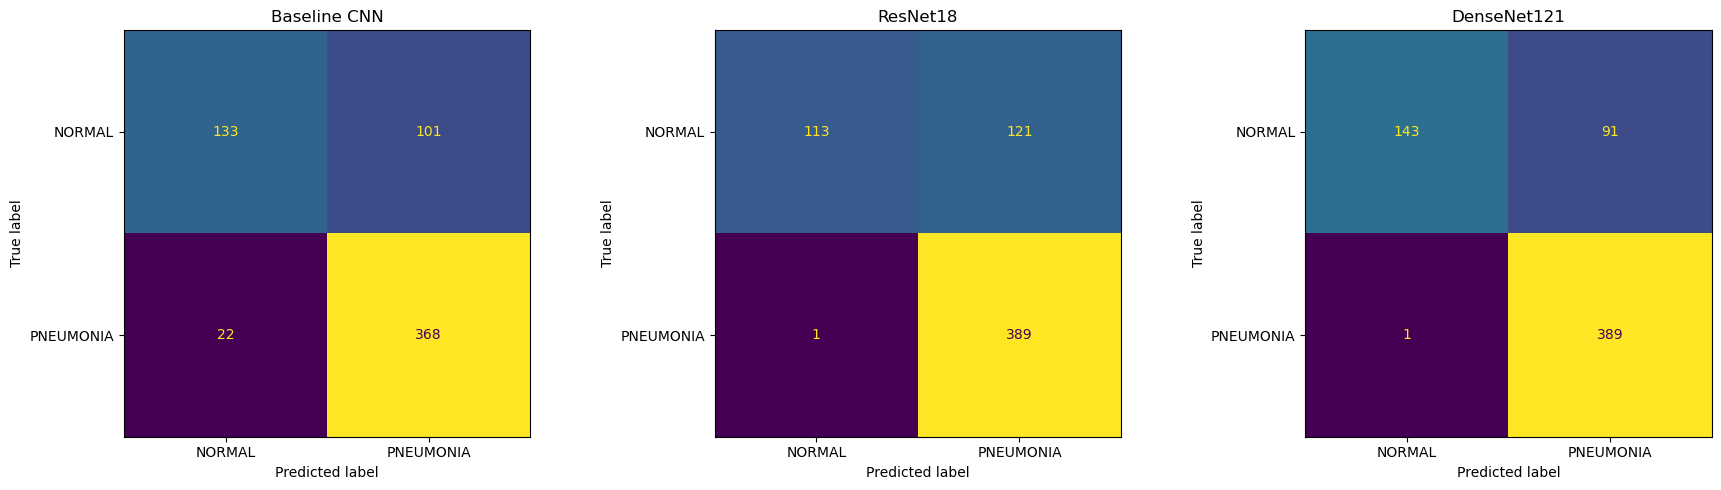

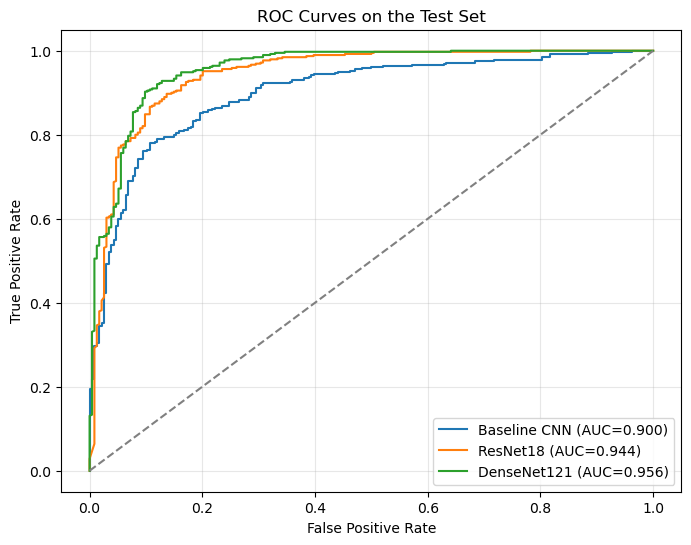

Baseline CNN: Accuracy=0.8029, Precision=0.7846, Recall=0.9436, F1=0.8568, ROC-AUC=0.8995
ResNet18: Accuracy=0.8045, Precision=0.7627, Recall=0.9974, F1=0.8644, ROC-AUC=0.9438
DenseNet121: Accuracy=0.8526, Precision=0.8104, Recall=0.9974, F1=0.8943, ROC-AUC=0.9557

Best model by ROC-AUC: DenseNet121


In [15]:
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    all_probabilities = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        probabilities = model(images).squeeze(1).detach().cpu().numpy()
        all_probabilities.extend(probabilities.tolist())
        all_labels.extend(labels.numpy().tolist())

    all_probabilities = np.array(all_probabilities)
    all_labels = np.array(all_labels)
    all_predictions = (all_probabilities >= 0.5).astype(int)
    return all_labels, all_predictions, all_probabilities

def evaluate_model(model, loader):
    labels, predictions, probabilities = collect_predictions(model, loader)
    metrics = {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1_score": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, probabilities),
        "confusion_matrix": confusion_matrix(labels, predictions),
    }
    fpr, tpr, _ = roc_curve(labels, probabilities)
    metrics["fpr"] = fpr
    metrics["tpr"] = tpr
    return metrics

evaluation_results = {}
for model_name, model in trained_models.items():
    evaluation_results[model_name] = evaluate_model(model, test_loader)

fig, axes = plt.subplots(1, len(evaluation_results), figsize=(18, 5))
if len(evaluation_results) == 1:
    axes = [axes]

for axis, (model_name, metrics_dict) in zip(axes, evaluation_results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=metrics_dict["confusion_matrix"],
        display_labels=class_names,
    )
    disp.plot(ax=axis, colorbar=False)
    axis.set_title(model_name)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, metrics_dict in evaluation_results.items():
    plt.plot(metrics_dict["fpr"], metrics_dict["tpr"], label=f"{model_name} (AUC={metrics_dict['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on the Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for model_name, metrics_dict in evaluation_results.items():
    print(
        f"{model_name}: "
        f"Accuracy={metrics_dict['accuracy']:.4f}, "
        f"Precision={metrics_dict['precision']:.4f}, "
        f"Recall={metrics_dict['recall']:.4f}, "
        f"F1={metrics_dict['f1_score']:.4f}, "
        f"ROC-AUC={metrics_dict['roc_auc']:.4f}"
    )

best_model_name = max(evaluation_results, key=lambda name: evaluation_results[name]["roc_auc"])
best_model = trained_models[best_model_name]
print(f"\nBest model by ROC-AUC: {best_model_name}")

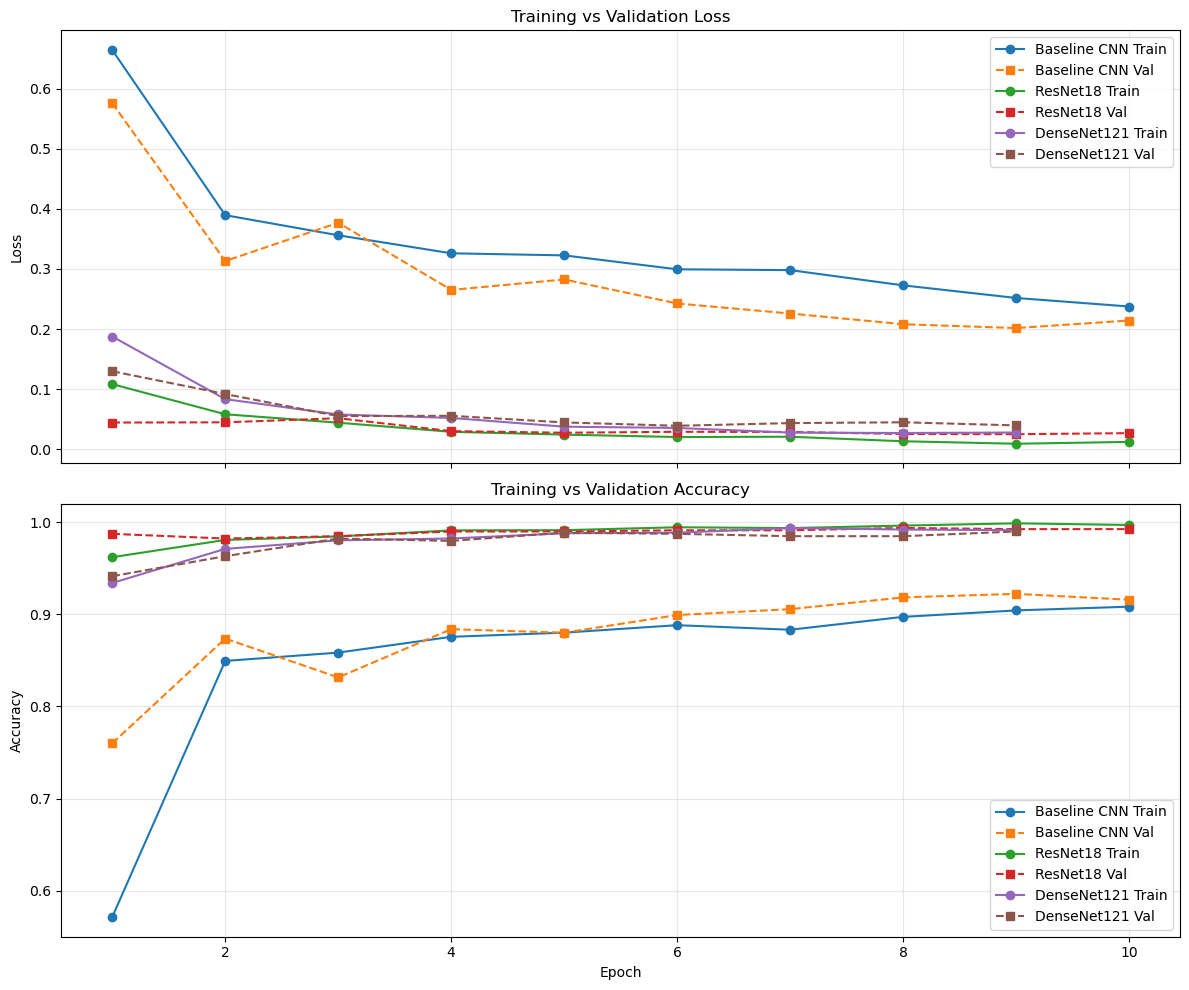

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for model_name, history in histories.items():
    epochs_range = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs_range, history["train_loss"], marker="o", label=f"{model_name} Train")
    axes[0].plot(epochs_range, history["val_loss"], marker="s", linestyle="--", label=f"{model_name} Val")

    axes[1].plot(epochs_range, history["train_acc"], marker="o", label=f"{model_name} Train")
    axes[1].plot(epochs_range, history["val_acc"], marker="s", linestyle="--", label=f"{model_name} Val")

axes[0].set_title("Training vs Validation Loss")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Grad-CAM Model Explainability

Grad-CAM highlights the image regions that most strongly influence a model decision by backpropagating gradients to a target convolutional layer. In pneumonia detection, this can help verify whether the model attends to plausible pulmonary regions rather than spurious artifacts or acquisition shortcuts.

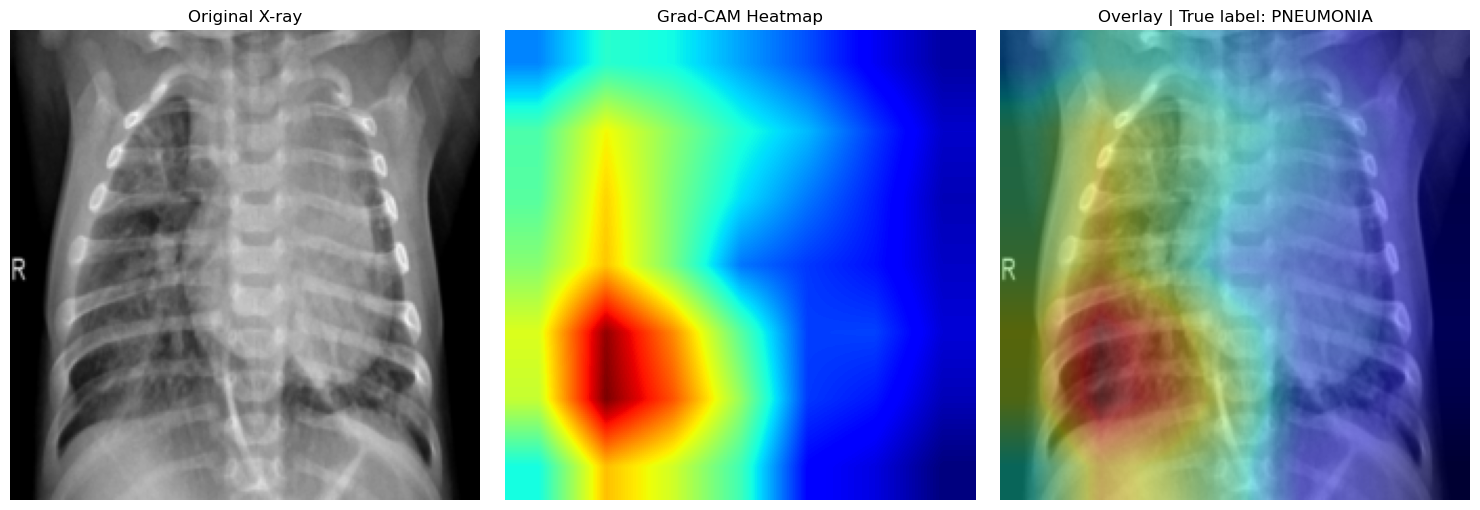

In [17]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handles = [
            target_layer.register_forward_hook(self._forward_hook),
            target_layer.register_full_backward_hook(self._backward_hook),
        ]

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad(set_to_none=True)
        output[:, 0].backward(torch.ones_like(output[:, 0]))

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = nn.functional.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def remove(self):
        for handle in self.handles:
            handle.remove()

def get_target_layer(model_name, model):
    if model_name == "Baseline CNN":
        return model.conv_block3[0]
    if model_name == "ResNet18":
        return model.layer4[-1].conv2
    if model_name == "DenseNet121":
        return model.features.denseblock4.denselayer16.conv2
    raise ValueError(f"Unsupported model for Grad-CAM: {model_name}")

def denormalize_tensor(image_tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    image_tensor = image_tensor.cpu() * std + mean
    return image_tensor.clamp(0, 1)

pneumonia_label = label_to_idx["PNEUMONIA"]
example_index = next(i for i, (_, label) in enumerate(test_samples) if label == pneumonia_label)
example_tensor, example_label = test_dataset[example_index]

input_tensor = example_tensor.unsqueeze(0).to(device)
target_layer = get_target_layer(best_model_name, best_model)
grad_cam = GradCAM(best_model, target_layer)
heatmap = grad_cam.generate(input_tensor)
grad_cam.remove()

display_image = denormalize_tensor(example_tensor, IMAGENET_MEAN, IMAGENET_STD).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(display_image)
axes[0].set_title("Original X-ray")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(display_image)
axes[2].imshow(heatmap, cmap="jet", alpha=0.4)
axes[2].set_title(f"Overlay | True label: {class_names[example_label]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [18]:
comparison_rows = []
for model_name, metrics_dict in evaluation_results.items():
    comparison_rows.append({
        "Model": model_name,
        "Best Val Loss": best_val_losses[model_name],
        "Accuracy": metrics_dict["accuracy"],
        "Precision": metrics_dict["precision"],
        "Recall": metrics_dict["recall"],
        "F1-score": metrics_dict["f1_score"],
        "ROC-AUC": metrics_dict["roc_auc"],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(comparison_df.style.format({
    "Best Val Loss": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
}))

,Model,Best Val Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,DenseNet121,0.0390,0.8526,0.8104,0.9974,0.8943,0.9557
1,ResNet18,0.0250,0.8045,0.7627,0.9974,0.8644,0.9438
2,Baseline CNN,0.2016,0.8029,0.7846,0.9436,0.8568,0.8995


In [19]:
def predict_xray(image_path, model=None, transform=eval_transform, class_names=class_names, device=device):
    if model is None:
        model = best_model

    model.eval()
    image = default_loader(image_path)
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        probability = model(tensor).item()

    predicted_index = int(probability >= 0.5)
    result = {
        "image_path": str(image_path),
        "predicted_class": class_names[predicted_index],
        "pneumonia_probability": probability,
        "normal_probability": 1.0 - probability,
    }
    return result

# Example usage:
# sample_result = predict_xray(test_samples[0][0])
# print(sample_result)

In [21]:
CHECKPOINT_DIR = Path("./model_artifacts")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = CHECKPOINT_DIR / f"{best_model_name.lower().replace(' ', '_')}_best.pth"

torch.save({
    "model_name": best_model_name,
    "state_dict": best_model.state_dict(),
    "class_names": class_names,
    "image_size": IMAGE_SIZE,
    "metrics": evaluation_results[best_model_name],
}, checkpoint_path)

def load_model_from_checkpoint(checkpoint_file, device=device):
    checkpoint = torch.load(checkpoint_file, map_location=device, weights_only=False)
    model_name = checkpoint["model_name"]
    model = model_builders[model_name]().to(device)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model, checkpoint

loaded_model, loaded_checkpoint = load_model_from_checkpoint(checkpoint_path)
print(f"Model saved to: {checkpoint_path.resolve()}")
print(f"Loaded model: {loaded_checkpoint['model_name']}")
print(f"Loaded ROC-AUC: {loaded_checkpoint['metrics']['roc_auc']:.4f}")

Model saved to: /home/kp2469/Pneumonia Project/checkpoints/densenet121_best.pth
Loaded model: DenseNet121
Loaded ROC-AUC: 0.9557


## Summary and Limitations

This notebook implemented three PyTorch pipelines for pneumonia detection from chest X-rays: a baseline CNN, transfer learning with ResNet-18, and transfer learning with DenseNet121. The workflow covered preprocessing, augmentation, training, evaluation, model comparison, Grad-CAM explainability, inference, and checkpointing.

Important limitations remain. The dataset is relatively small and imbalanced, labels may contain noise, and there is no supporting clinical metadata such as age, symptoms, vitals, or laboratory findings. The data also reflects specific acquisition settings and population characteristics, so models trained here may not generalize reliably across hospitals, devices, or demographic groups. These models are therefore suitable for research and education, not direct clinical deployment without external validation and regulatory review.